# Stock-to-Flow — a quantitative teardown 🔬
### The spurious-regression race · the frozen out-of-sample R² collapse · a HAC residual→return regression · a timer vs buy-and-hold · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Holds_out--of--sample%3F: Busted](https://img.shields.io/badge/Holds_out--of--sample%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — `ln(price) = a + b·ln(SF)` with in-sample R² ≈ 0.95 — is tested three ways: **(1)** is the fit real or a spurious regression of two non-stationary trending series; **(2)** does it survive frozen at its publication date; **(3)** is the valuation residual a tradable signal net of costs. The S2F curve is **reconstructed from Bitcoin's exact issuance schedule** — consensus law, not a proxy.

> ⚠️ **Data note.** S2F reconstructed from the halving schedule (stock exact at every halving, flow = reward × 144 blocks/day × 365). BTC-USD daily close, yfinance, 2014-09-17 → 2026-06-30 (fingerprint `74d40e852645`). Price-only == total-return for BTC. No survivorship on the Signal axis (single-asset index); BTC's single-survivor character is named on Tradability. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stock_to_flow import data, strategy as st

SF = data.supply_flow_daily()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    BTC = data.load_btc()
    DF = data.join_price_sf(BTC)
    OOS = st.oos_fit_stats(DF, data.PUBLICATION_DATE)
    A, B = OOS["a"], OOS["b"]
    MODEL = st.model_price(DF, A, B)
    RESID = st.valuation_residual(DF, A, B)
else:
    BTC = DF = OOS = A = B = MODEL = RESID = None
print("real cache present:", HAVE_REAL, "| S2F curve points:", len(SF),
      "| SF today:", round(float(SF['sf'].iloc[-1] if not HAVE_REAL else DF['sf'].iloc[-1]), 1))

# frozen headline numbers (mirror of docs/results.md)
R = {'btc_lo': '2014-09-17', 'btc_hi': '2026-06-30', 'btc_n': 4305, 'fp': '74d40e852645', 'sf_now': 122, 'supply_now_m': 20.05, 'pub': '2019-03-22', 'steel_r2': 0.8866, 'steel_b': 2.458, 'steel_n': 142, 'r2_sf': 0.8803, 'r2_time': 0.8758, 'corr_sf_time': 0.9643, 'a': -0.8711, 'b': 2.7661, 'n_train': 1648, 'n_oos': 2657, 'r2_in': 0.705, 'r2_oos': 0.2132, 'rmse_in': 0.739, 'rmse_oos': 0.7702, 'pred': {'2021-11-30': (57005, 30857, 1.85), '2022-11-30': (17169, 32384, 0.53), '2024-12-31': (93429, 239071, 0.39), '2026-06-30': (58559, 247369, 0.24)}, 'fwd': {30: (-0.015, -0.62, -1.48), 90: (-0.121, -1.51, -2.5), 180: (-0.435, -1.68, -2.81), 365: (-0.187, -0.45, -1.64)}, 'oos_expo': 59, 'oos_switches': 9, 'oos_years': 7.3, 'oos_net': 328, 'oos_gross': 332, 'oos_net_sharpe': 0.71, 'oos_bh': 1355, 'oos_bh_sharpe': 0.91, 'oos_plac_mean': 87, 'oos_plac_p95': 409, 'p21_expo': 78, 'p21_years': 4.7, 'p21_net': 7, 'p21_bh': -4, 'p21_net_sharpe': 0.25, 'p21_bh_sharpe': 0.24, 'p21_plac_mean': -39, 'p21_plac_p95': 17, 'syn_null_mean': 0.17, 'syn_null_sd': 1.29, 'syn_null_fire': 5, 'syn_planted': -5.96}


real cache present: True | S2F curve points: 6938 | SF today: 122.1


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | out-of-sample residual→return HAC *t* peaks at **-1.68** (180d); full-sample R² ≈ 0.88 matches a time-trend's 0.88 (corr 0.96) — spurious |
| **Tradability** | `MIRAGE` | timer **+328%** vs B&H **+1,355%** OOS (Sharpe 0.71 vs 0.91), below the random-timing p95 (+409%) |
| **Holds out-of-sample?** | `BUSTED` | frozen-at-pub R² 0.705 → 0.213; model/actual = 0.24 by 2026 |

> 💡 In plain words: the model *describes* the past because both its inputs trend with time; it *predicts* nothing because a trend is not a mechanism.

## 1 · The claim, steelmanned

Let $P_t$ be BTC price and $SF_t = \text{stock}_t / \text{flow}_t$ the stock-to-flow ratio, both observed daily. PlanB's model:

$$\ln P_t = a + b\,\ln SF_t + \varepsilon_t, \qquad R^2 \approx 0.95.$$

- **H₁ (the model is real).** $b$ is a structural elasticity of price to scarcity, and $\varepsilon_t$ is stationary noise around a true relationship — so the fitted line is a *valuation*, usable out-of-sample.
- **H₂ (tradable).** The residual $\varepsilon_t$ mean-reverts: when price is below the line ($\varepsilon_t < 0$, "cheap"), forward returns are positive.

The steelman fit uses PlanB's own dependent variable (market cap, monthly): on our sample R² = **0.8866** (n = 142 months), b = 2.458. The whole question is whether that number means anything — because both $\ln P_t$ and $\ln SF_t$ are **non-stationary and trending**, the exact setting where OLS R² and *t* are known to be spurious (Granger–Newbold 1974).

## 2 · So what? — the spurious-regression problem

$\ln SF_t$ is a near-deterministic function of the block height: it is flat within a halving epoch and doubles at each halving, so it rises monotonically with calendar time. Regressing one trending (integrated) series on another manufactures high R² and large *t* even when the two are causally unrelated — the classic spurious regression. The clean diagnostic: **race the S2F fit against a fit on time itself.** If $\ln P_t \sim \text{time}$ fits as well as $\ln P_t \sim \ln SF_t$, then S2F is contributing nothing but a clock, and the reported R² certifies scarcity of *nothing*.

## 3 · How we'd know — the protocol

- **S2F curve.** Reconstructed from the issuance schedule; stock exact at each halving (10.5M/15.75M/18.375M/19.6875M), flow = reward × 144 × 365, SF doubling per halving; SF today ≈ 122.
- **Tape.** BTC-USD daily close 2014-09-17 → 2026-06-30 (4,305 rows), as-of 2026-06-30 (last complete month). Note: yfinance BTC-USD begins 2014-09, so our in-sample window is shorter than PlanB's 2009-start fit — named.
- **Spurious race.** R²(price~lnSF) vs R²(price~time), and corr(lnSF, time).
- **Honest OOS.** Fit on data ≤ **2019-03-22** (publication; 1,648 days), freeze $a,b$, score the untouched 2,657 days after.
- **Signal.** Overlapping forward returns (30/90/180/365d) on the lagged residual, Newey-West *t* at lag 1.5× horizon; **REAL needs a negative slope with |t| ≥ 2 out-of-sample.**
- **Execution.** Residual known at *t*'s close → position from *t+1* (one-day lag); 10 bps one-way × NAV per switch; gross AND net; matched-exposure random-timing placebo.
- **Control.** Synthetic world with an exogenous stationary valuation gap and a tunable planted mean-reversion coefficient; the null must read ~0 across 20 seeds.

## 4 · The teardown

### 4a · The fit is a clock — the spurious-regression race

Full-sample OLS, daily. If scarcity mattered beyond the trend, the S2F fit would clearly beat a naive time-trend. It does not.

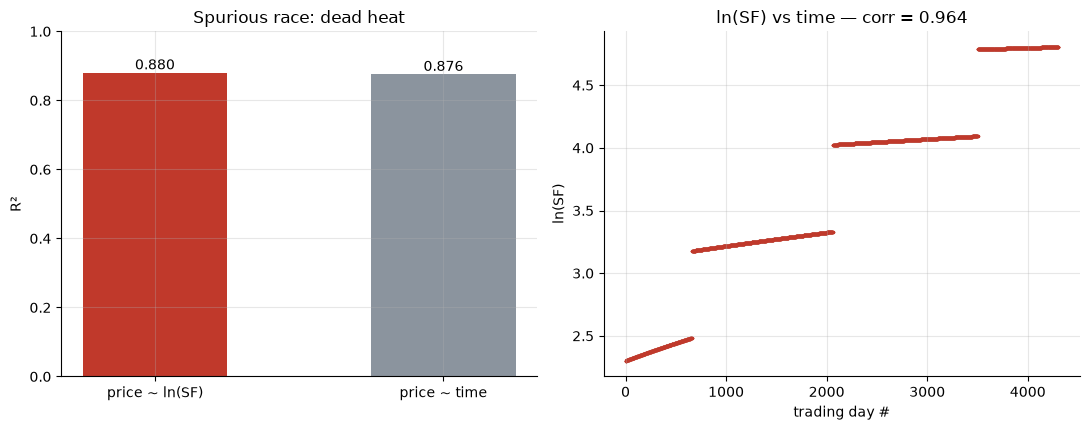

R2(price~lnSF)=0.8803  R2(price~time)=0.8758  corr(lnSF,time)=0.9643


In [2]:
if HAVE_REAL:
    race = st.spurious_trend_race(DF)
    r2_sf, r2_time, corr = race['r2_sf'], race['r2_time'], race['corr_sf_time']
    y = np.log(DF['price'].values); x = np.log(DF['sf'].values); t = np.arange(len(DF))
else:
    r2_sf, r2_time, corr = R['r2_sf'], R['r2_time'], R['corr_sf_time']
    y = x = t = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['price ~ ln(SF)', 'price ~ time'], [r2_sf, r2_time], color=[RED, GREY], width=.5)
for i, v in enumerate([r2_sf, r2_time]): a1.annotate(f'{v:.3f}', (i, v), ha='center', va='bottom')
a1.set_ylim(0, 1); a1.set_ylabel('R²'); a1.set_title('Spurious race: dead heat')
if HAVE_REAL:
    a2.scatter(t, x, s=2, color=RED, label='ln(SF)')
    a2.set_xlabel('trading day #'); a2.set_ylabel('ln(SF)')
    a2.set_title(f'ln(SF) vs time — corr = {corr:.3f}')
else:
    a2.text(.5,.5,f'corr(lnSF,time)={corr:.3f}',ha='center')
plt.tight_layout(); plt.show()
print(f'R2(price~lnSF)={r2_sf:.4f}  R2(price~time)={r2_time:.4f}  corr(lnSF,time)={corr:.4f}')

> 💡 In plain words: R² 0.880 vs 0.876 is a statistical dead heat, and ln(SF) is 96% correlated with the day counter. The model's explanatory power is the trend, relabelled "scarcity." Under non-stationarity the reported R² and *t* are exactly the quantities Granger–Newbold warned are meaningless.

### 4b · Freeze it at publication — the out-of-sample collapse

Fit on data ≤ 2019-03-22, freeze $a = -0.8711, b = 2.7661$, score forward with the frozen line (so OOS R² can go negative).

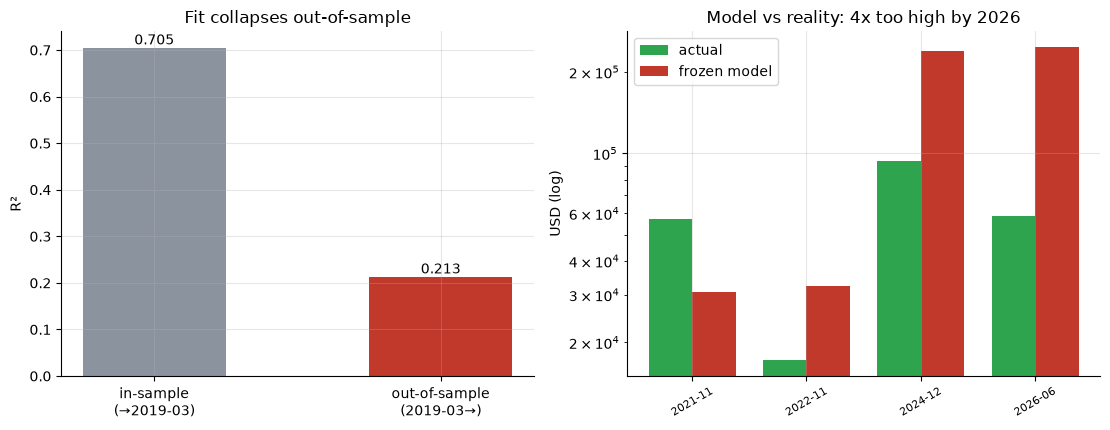

2021-11-30: actual $57,005  model $30,857  ratio 1.85
2022-11-30: actual $17,169  model $32,384  ratio 0.53
2024-12-31: actual $93,429  model $239,071  ratio 0.39
2026-06-30: actual $58,559  model $247,369  ratio 0.24


In [3]:
if HAVE_REAL:
    o = st.oos_fit_stats(DF, data.PUBLICATION_DATE)
    r2_in, r2_oos = o['r2_in'], o['r2_oos']
    pred = {d: (float(DF.loc[DF.index<=pd.Timestamp(d),'price'].iloc[-1]),
                float(MODEL.loc[MODEL.index<=pd.Timestamp(d)].iloc[-1]))
            for d in R['pred']}
else:
    r2_in, r2_oos = R['r2_in'], R['r2_oos']
    pred = {d: (v[0], v[1]) for d, v in R['pred'].items()}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(['in-sample\n(→2019-03)', 'out-of-sample\n(2019-03→)'], [r2_in, r2_oos], color=[GREY, RED], width=.5)
for i, v in enumerate([r2_in, r2_oos]): a1.annotate(f'{v:.3f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('R²'); a1.set_title('Fit collapses out-of-sample')
ds = list(pred.keys()); act = [pred[d][0] for d in ds]; mod = [pred[d][1] for d in ds]
xp = np.arange(len(ds)); w = 0.38
a2.bar(xp - w/2, act, width=w, color=GREEN, label='actual')
a2.bar(xp + w/2, mod, width=w, color=RED, label='frozen model')
a2.set_yscale('log'); a2.set_xticks(xp); a2.set_xticklabels([d[:7] for d in ds], rotation=30, fontsize=8)
a2.set_ylabel('USD (log)'); a2.set_title('Model vs reality: 4x too high by 2026'); a2.legend()
plt.tight_layout(); plt.show()
for d in ds: print(f'{d}: actual ${pred[d][0]:,.0f}  model ${pred[d][1]:,.0f}  ratio {pred[d][0]/pred[d][1]:.2f}')

> 💡 In plain words: in-sample R² 0.70 → out-of-sample 0.21. The frozen model **under**-shot into the 2021 top, then as SF doubled at the 2024 halving its prediction rocketed to $247,369 while price sat at $58,559 — a factor of four. A model that predicted a six-figure *floor* straight through the 2022 crash to $17k is not a valuation; it's a curve fit that ran out of past.

### 4c · Is the residual tradable? — HAC regression + timer

Left: forward BTC returns regressed on the lagged valuation residual, Newey-West *t*, **out-of-sample** (frozen coefficients — no look-ahead). Right: the long-when-cheap timer vs buy-and-hold, net of costs.

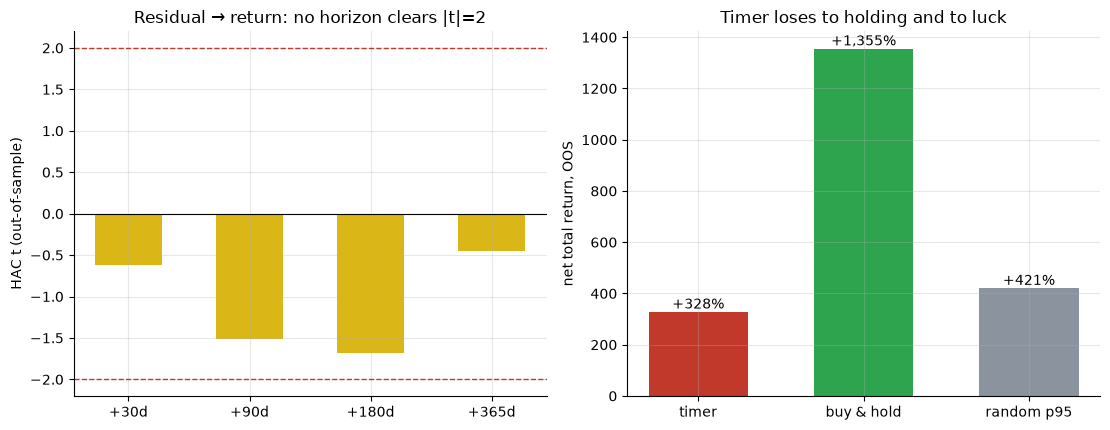

+30d HAC t (OOS) = -0.62
+90d HAC t (OOS) = -1.51
+180d HAC t (OOS) = -1.68
+365d HAC t (OOS) = -0.45
timer +328% vs hold +1355% vs random-p95 +421%


In [4]:
if HAVE_REAL:
    prO = st.predictive_regression(DF, RESID, window_start=data.PUBLICATION_DATE)
    hz = list(prO.index); ts = list(prO['hac_t'])
    tb = st.timer_backtest(DF, RESID, threshold=0.0, cost_bps=10.0, window_start=data.PUBLICATION_DATE)
    st_net, bh, plac = tb['net_total_pct'], tb['bh_total_pct'], None
    pl = st.random_placebo(DF, tb['exposure_pct'], cost_bps=10.0, window_start=data.PUBLICATION_DATE, n_draws=2000)
    plac = pl['p95_total_pct']
else:
    hz = [30, 90, 180, 365]; ts = [R['fwd'][h][1] for h in hz]
    st_net, bh, plac = R['oos_net'], R['oos_bh'], R['oos_plac_p95']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
x = np.arange(len(hz))
a1.bar(x, ts, color=[RED if abs(v) >= 2 else AMBER for v in ts], width=.55)
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xticks(x); a1.set_xticklabels([f'+{h}d' for h in hz]); a1.set_ylabel('HAC t (out-of-sample)')
a1.set_title('Residual → return: no horizon clears |t|=2')
a2.bar(['timer', 'buy & hold', 'random p95'], [st_net, bh, plac], color=[RED, GREEN, GREY], width=.6)
for i, v in enumerate([st_net, bh, plac]): a2.annotate(f'{v:+,.0f}%', (i, v), ha='center', va='bottom')
a2.set_ylabel('net total return, OOS'); a2.set_title('Timer loses to holding and to luck')
plt.tight_layout(); plt.show()
for h, v in zip(hz, ts): print(f'+{h}d HAC t (OOS) = {v:+.2f}')
print(f'timer {st_net:+.0f}% vs hold {bh:+.0f}% vs random-p95 {plac:+.0f}%')

> 💡 In plain words: out-of-sample, the best HAC *t* is **-1.68** (180d) — the slope has the "buy cheap" sign, but nowhere near significant. (The full-sample version *does* cross 2 at 90/180d — but the residual is defined against a line fit on that same data, so that's the fit grading its own homework, not evidence.) And the timer earns **+328%** where holding earns **+1,355%** and even random buy dates' luckiest 5% reach **+409%**. No signal, no edge.

### 4d · The post-2021 "broke" window, on its own

The model became a meme *after* 2021, so test the rule only there (2021-11 → today) — the window where believers said it would still call the bottom.

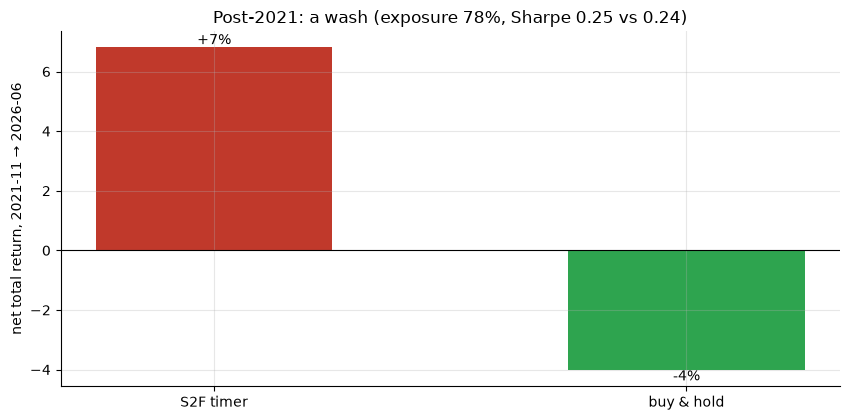

post-2021: timer +7% (Sharpe 0.25) vs hold -4% (Sharpe 0.24), exposure 78%


In [5]:
if HAVE_REAL:
    tb2 = st.timer_backtest(DF, RESID, threshold=0.0, cost_bps=10.0, window_start='2021-11-01')
    net, bh2, expo = tb2['net_total_pct'], tb2['bh_total_pct'], tb2['exposure_pct']
    ns, bs = tb2['net_sharpe'], tb2['bh_sharpe']
else:
    net, bh2, expo = R['p21_net'], R['p21_bh'], R['p21_expo']
    ns, bs = R['p21_net_sharpe'], R['p21_bh_sharpe']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
b = ax.bar(['S2F timer', 'buy & hold'], [net, bh2], color=[RED, GREEN], width=.5)
for i, v in enumerate([net, bh2]): ax.annotate(f'{v:+.0f}%', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net total return, 2021-11 → 2026-06')
ax.set_title(f'Post-2021: a wash (exposure {expo:.0f}%, Sharpe {ns:.2f} vs {bs:.2f})')
plt.tight_layout(); plt.show()
print(f'post-2021: timer {net:+.0f}% (Sharpe {ns:.2f}) vs hold {bh2:+.0f}% (Sharpe {bs:.2f}), exposure {expo:.0f}%')

> 💡 In plain words: +7% vs -4% — a coin-flip. Once the model line explodes above the price, the residual is negative essentially every day, so the rule reads "always cheap, always long" (exposure 78%) and just *becomes* buy-and-hold. The signal doesn't fail dramatically; it dissolves into the thing it was supposed to beat.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic world: an exogenous *stationary* valuation gap and an explicitly-planted mean-reversion coefficient `beta`. The detector regresses forward returns on the gap. The null (`beta = 0`, gap carries no return information) is checked over **20 seeds**.

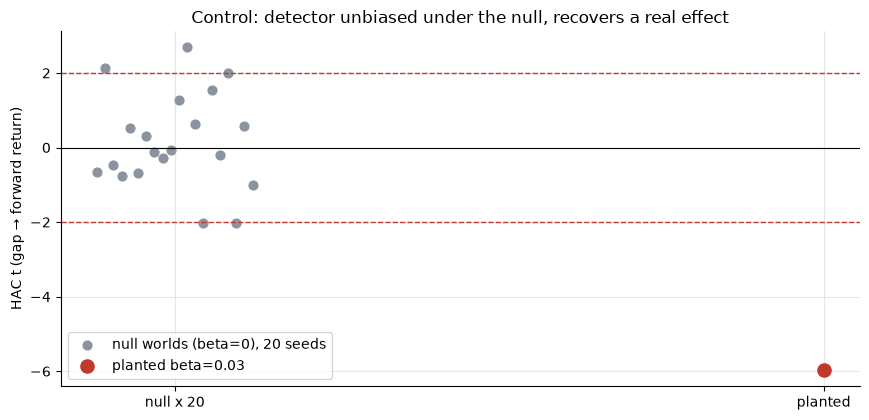

null: mean t = +0.17 (sd 1.29), |t|>=2 in 5/20  |  planted t = -5.96


In [6]:
null_ts = np.array([st.synthetic_detect(data.synthetic_world(beta=0.0, seed=765 + s)) for s in range(20)])
planted = st.synthetic_detect(data.synthetic_world(beta=0.03, seed=765))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40, label='null worlds (beta=0), 20 seeds')
ax.scatter([1], [planted], color=RED, s=90, zorder=5, label='planted beta=0.03')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('HAC t (gap → forward return)')
ax.set_title('Control: detector unbiased under the null, recovers a real effect')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20  |  planted t = {planted:+.2f}')

> 💡 In plain words: the detector recovers a planted valuation signal cleanly (t = -5.96) and is unbiased under the null (mean +0.17). But note the null's *spread*: 5/20 seeds cross |t| = 2 by chance, because overlapping windows and a persistent regressor inflate the tails — the very mechanism that makes the real full-sample *t*'s untrustworthy. It is exactly why we bar the Signal stamp on anything short of a clean **out-of-sample** |t| ≥ 2. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the full-sample R² ≈ 0.88 is a spurious regression: ln(SF) is 96% correlated with time and a plain time-trend fits equally well (0.88). Out-of-sample the residual predicts forward returns at no horizon with |t| ≥ 2 (best -1.68, 180d).
- **Tradability `MIRAGE`** — the long-when-cheap timer returns +328% net vs buy-and-hold's +1,355% out-of-sample (Sharpe 0.71 vs 0.91), below the matched-exposure random-timing p95 (+409%); post-2021 it collapses to buy-and-hold (+7% vs -4%).
- **"Holds out-of-sample?" `BUSTED`** — coefficients frozen at publication, R² falls 0.705 → 0.213; the model implied a six-figure BTC floor through the 2022 crash to $17k and stands 0.24× of the tape by 2026 ($247,369 model vs $58,559 actual).

## 6 · Going further

- **The cointegration objection, and why it doesn't save it.** A defender might say price and SF are *cointegrated* rather than spuriously correlated. But cointegration is a testable claim about a *stationary* residual that mean-reverts to a tradable spread — and §4c shows the residual neither predicts returns OOS nor pays. Absent that, "cointegrated" is just "spurious" wearing a better coat.
- **What a real rescue would need:** an out-of-sample residual→return |t| ≥ 2, or a timer that beats both buy-and-hold and the random-timing placebo net of costs. Neither exists on this tape at any of four horizons.
- **Dedup map:** [323-btc-halving](../../323-btc-halving/) (the halving as a calendar event, not a valuation level), [293-mvrv-ratio](../../293-mvrv-ratio/) (a market-derived on-chain valuation ratio and mean-reversion timer), [663-hash-ribbons](../../663-hash-ribbons/) (a miner-capitulation discrete buy signal), [221-mayer-multiple](../../221-mayer-multiple/) (price/200-day-SMA bands), [210-crypto-trend](../../210-crypto-trend/) (200-day price SMA trend-following). None test PlanB's literal `ln(price) ~ ln(SF)` level model.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*